In [ ]:
'''
============================================================
SCCAF clustering optimization

Purpose: 
This script performs SCCAF-based refinement of 
seurat clusters on a CCA-integrated dataset.

Additional Notes: 
SCCAF (Single Cell Clustering Assessment and Feature Selection) 
is a machine-learning method used to refine and optimize 
single-cell RNA-seq cluster assignments by iteratively improving 
cluster separation based on gene expression features.

https://doi.org/10.1038/s41592-020-0825-9 # link to paper 
https://github.com/SCCAF/sccaf # link to github
============================================================
'''

In [ ]:
%pylab inline

import warnings
warnings.filterwarnings("ignore")
from SCCAF import *
import urllib.request
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import seaborn as sns
import inspect
import scipy
import loompy
import gseapy as gp
import plotly.graph_objects as go
from SCCAF import SCCAF_assessment, plot_roc
import scanpy as sc
import random

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [ ]:
# Save everything 
sc.settings.autosave = True

# Make sure you see all columns in your pandas
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Better resolution
sc.settings.njobs = 32
sc.set_figure_params(frameon=False, dpi=150, fontsize=10, dpi_save=600)

In [ ]:
# Set directory
os.chdir("path/to/folder")

In [ ]:
# Read in the data
adata = sc.read_h5ad("path/to/allcells_cca_integrated.h5ad")

In [ ]:
# Make sure to bring in clusters at all resolutions specifically using specifcially the CCA integration 
adata.obsm['umap_cell_embeddings'] = adata.obsm['X_umap']
adata.obsm['pca_cell_embeddings'] = adata.obsm['X_pca']
adata

AnnData object with n_obs × n_vars = 59037 × 24987
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'sampleID', 'batch', 'sample_batch', 'percent.mito', 'scDblFinder.sample', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'nCount_SCT', 'nFeature_SCT', 'seurat_clusters', 'merged_res_0.02', 'merged_res_0.04', 'merged_res_0.06', 'merged_res_0.08', 'merged_res_0.1', 'rpca_clusters', 'harmony_clusters', 'cca_clusters', 'cca_res_0.01', 'cca_res_0.02', 'cca_res_0.03', 'cca_res_0.04', 'cca_res_0.05', 'cca_res_0.06', 'cca_res_0.07', 'cca_res_0.08', 'cca_res_0.09', 'cca_res_0.1', 'Male_Cells1', 'Female_Cells1', 'sex1', 'sex2', 'sex'
    var: 'names'
    obsm: 'X_integrated.cca', 'X_pca', 'X_umap', 'X_umap.cca', 'umap_cell_embeddings', 'pca_cell_embeddings'
    layers: 'counts_SCT'

In [ ]:
# Read your CSV with your highly variable genes
gene_df = pd.read_csv('path/to/sct_hvg.csv')

# Extract the gene list
hb_genes = set(gene_df['x'].tolist())

# Initialize the new column to False
adata.var['highly_variable'] = False

# Mark True for genes present in your list
adata.var.loc[adata.var['names'].isin(hb_genes), 'highly_variable'] = True

# Check it worked 
print(adata.var['highly_variable'].value_counts())

False    21987
True      3000
Name: highly_variable, dtype: int64


In [143]:
# Set this to be your slightly over clustered resolution
adata.obs['L1_Round0'] = adata.obs['cca_res_0.03']

R1norm_cutoff: 0.500000
R2norm_cutoff: 0.050000
Accuracy: 0.000000
Round1 ...
Mean CV accuracy: 0.9818
Accuracy on the training set: 1.0000
Accuracy on the hold-out set: 0.9879


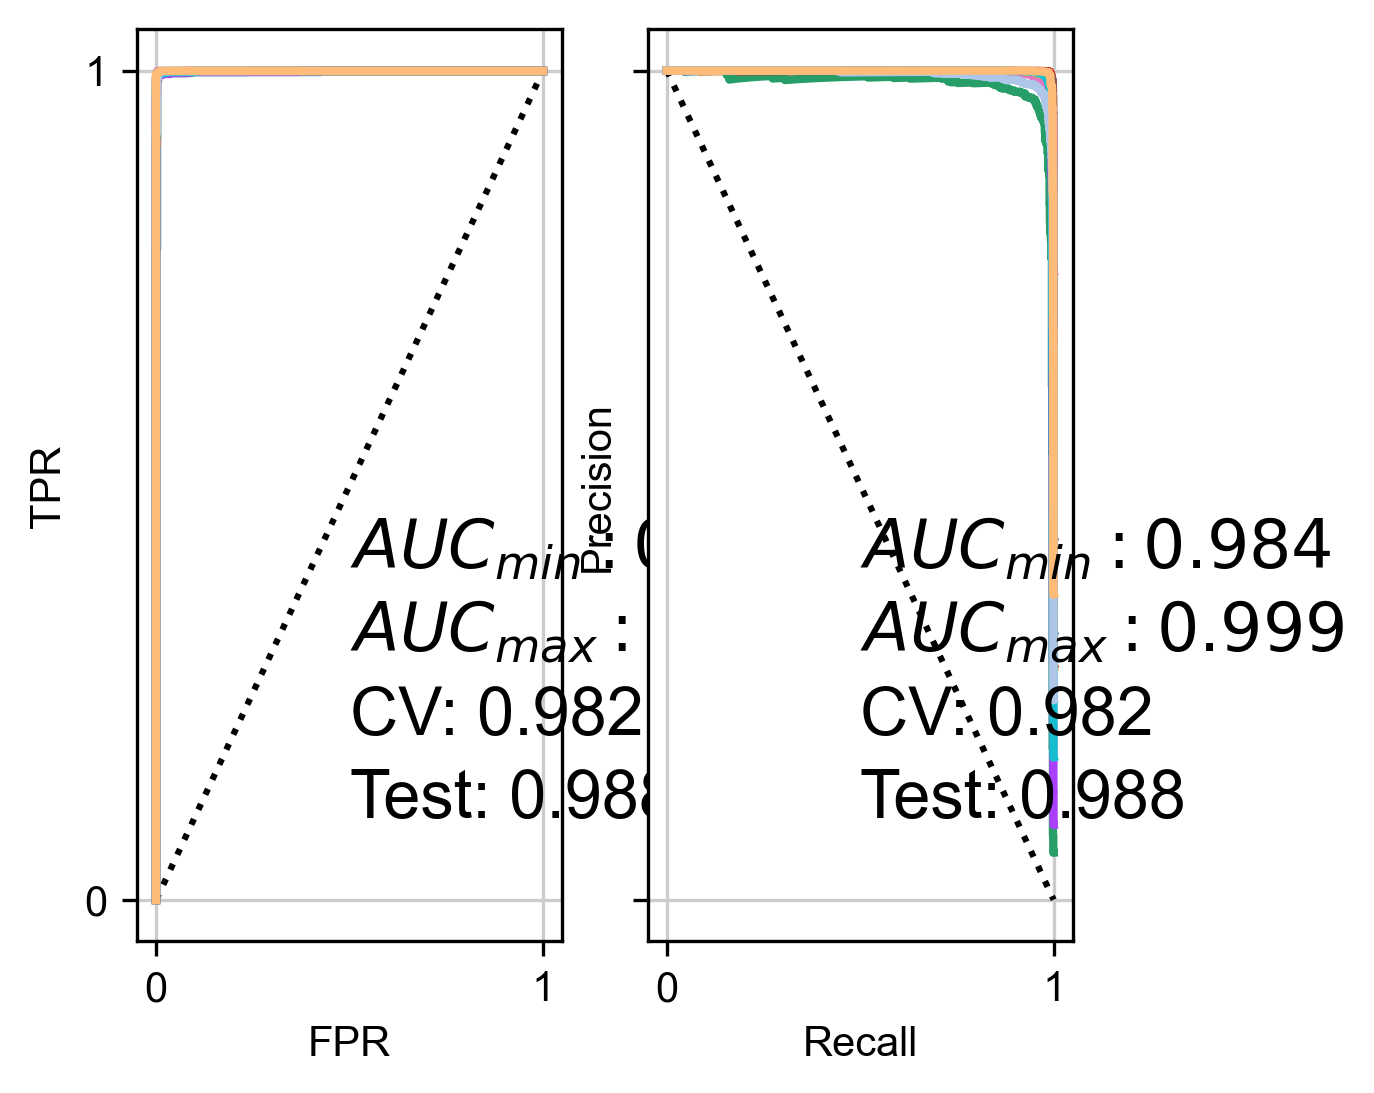

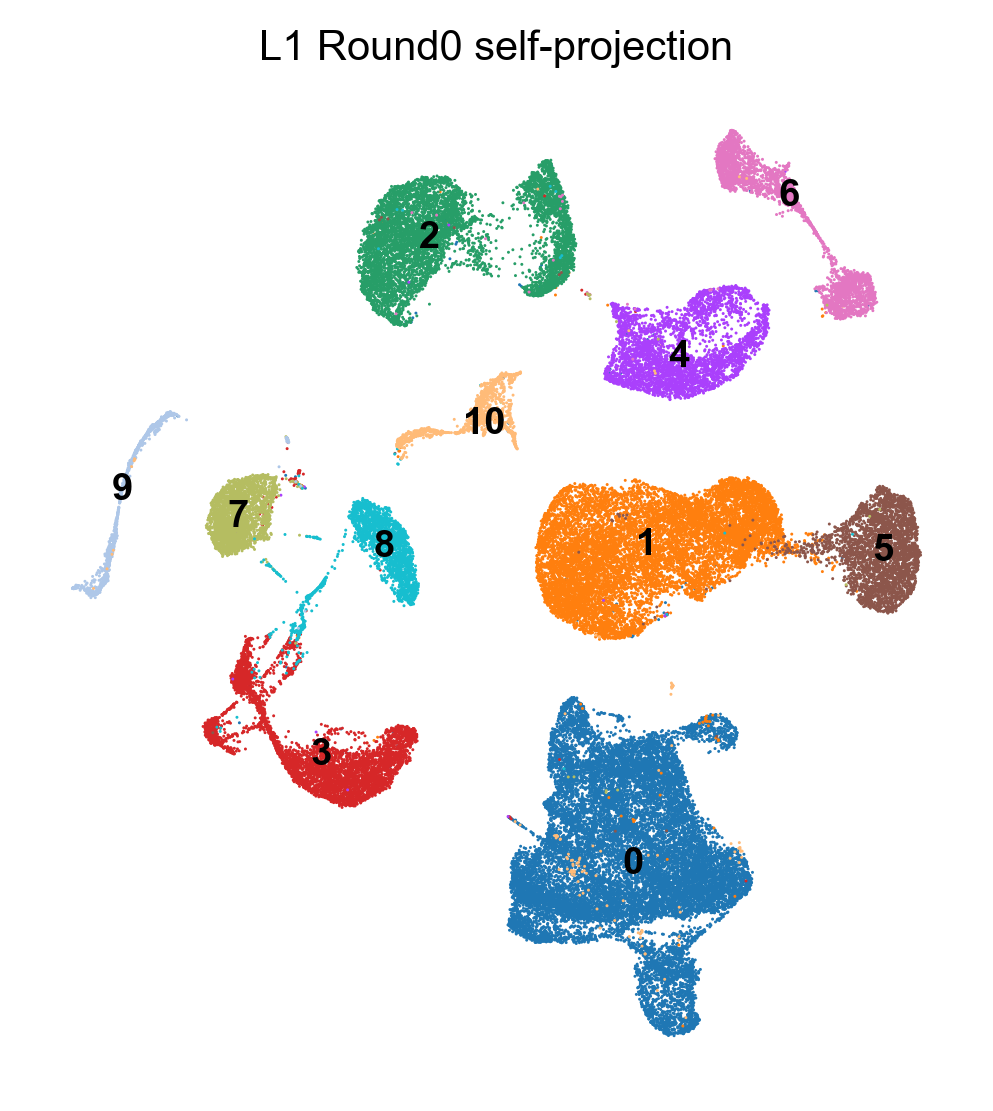

Accuracy on the training set: 1.0000
Accuracy on the hold-out set: 0.9855
Accuracy on the training set: 0.9991
Accuracy on the hold-out set: 0.9851
Max R1mat: 0.040889
Max R2mat: 0.001652
Converge SCCAF_optimize min_acc!
m1: 0.040889
m2: 0.001652
Accuracy: 0.985105


In [ ]:
# Set the seeds to ensure reproducibility because this process is annoyingly random 
random.seed(12345)
np.random.seed(12345)

# Set low_res to be slightly under clustered resolution. 
SCCAF_optimize_all(
    ad = adata, 
    min_acc = 0.95, 
    prefix = 'L1', 
    low_res = 'chosen_integration_res_0.01', 
    use = 'highly_variable', 
    n_iter = 150, 
    R1norm_step=0.00005, 
    R2norm_step=0.00005
)

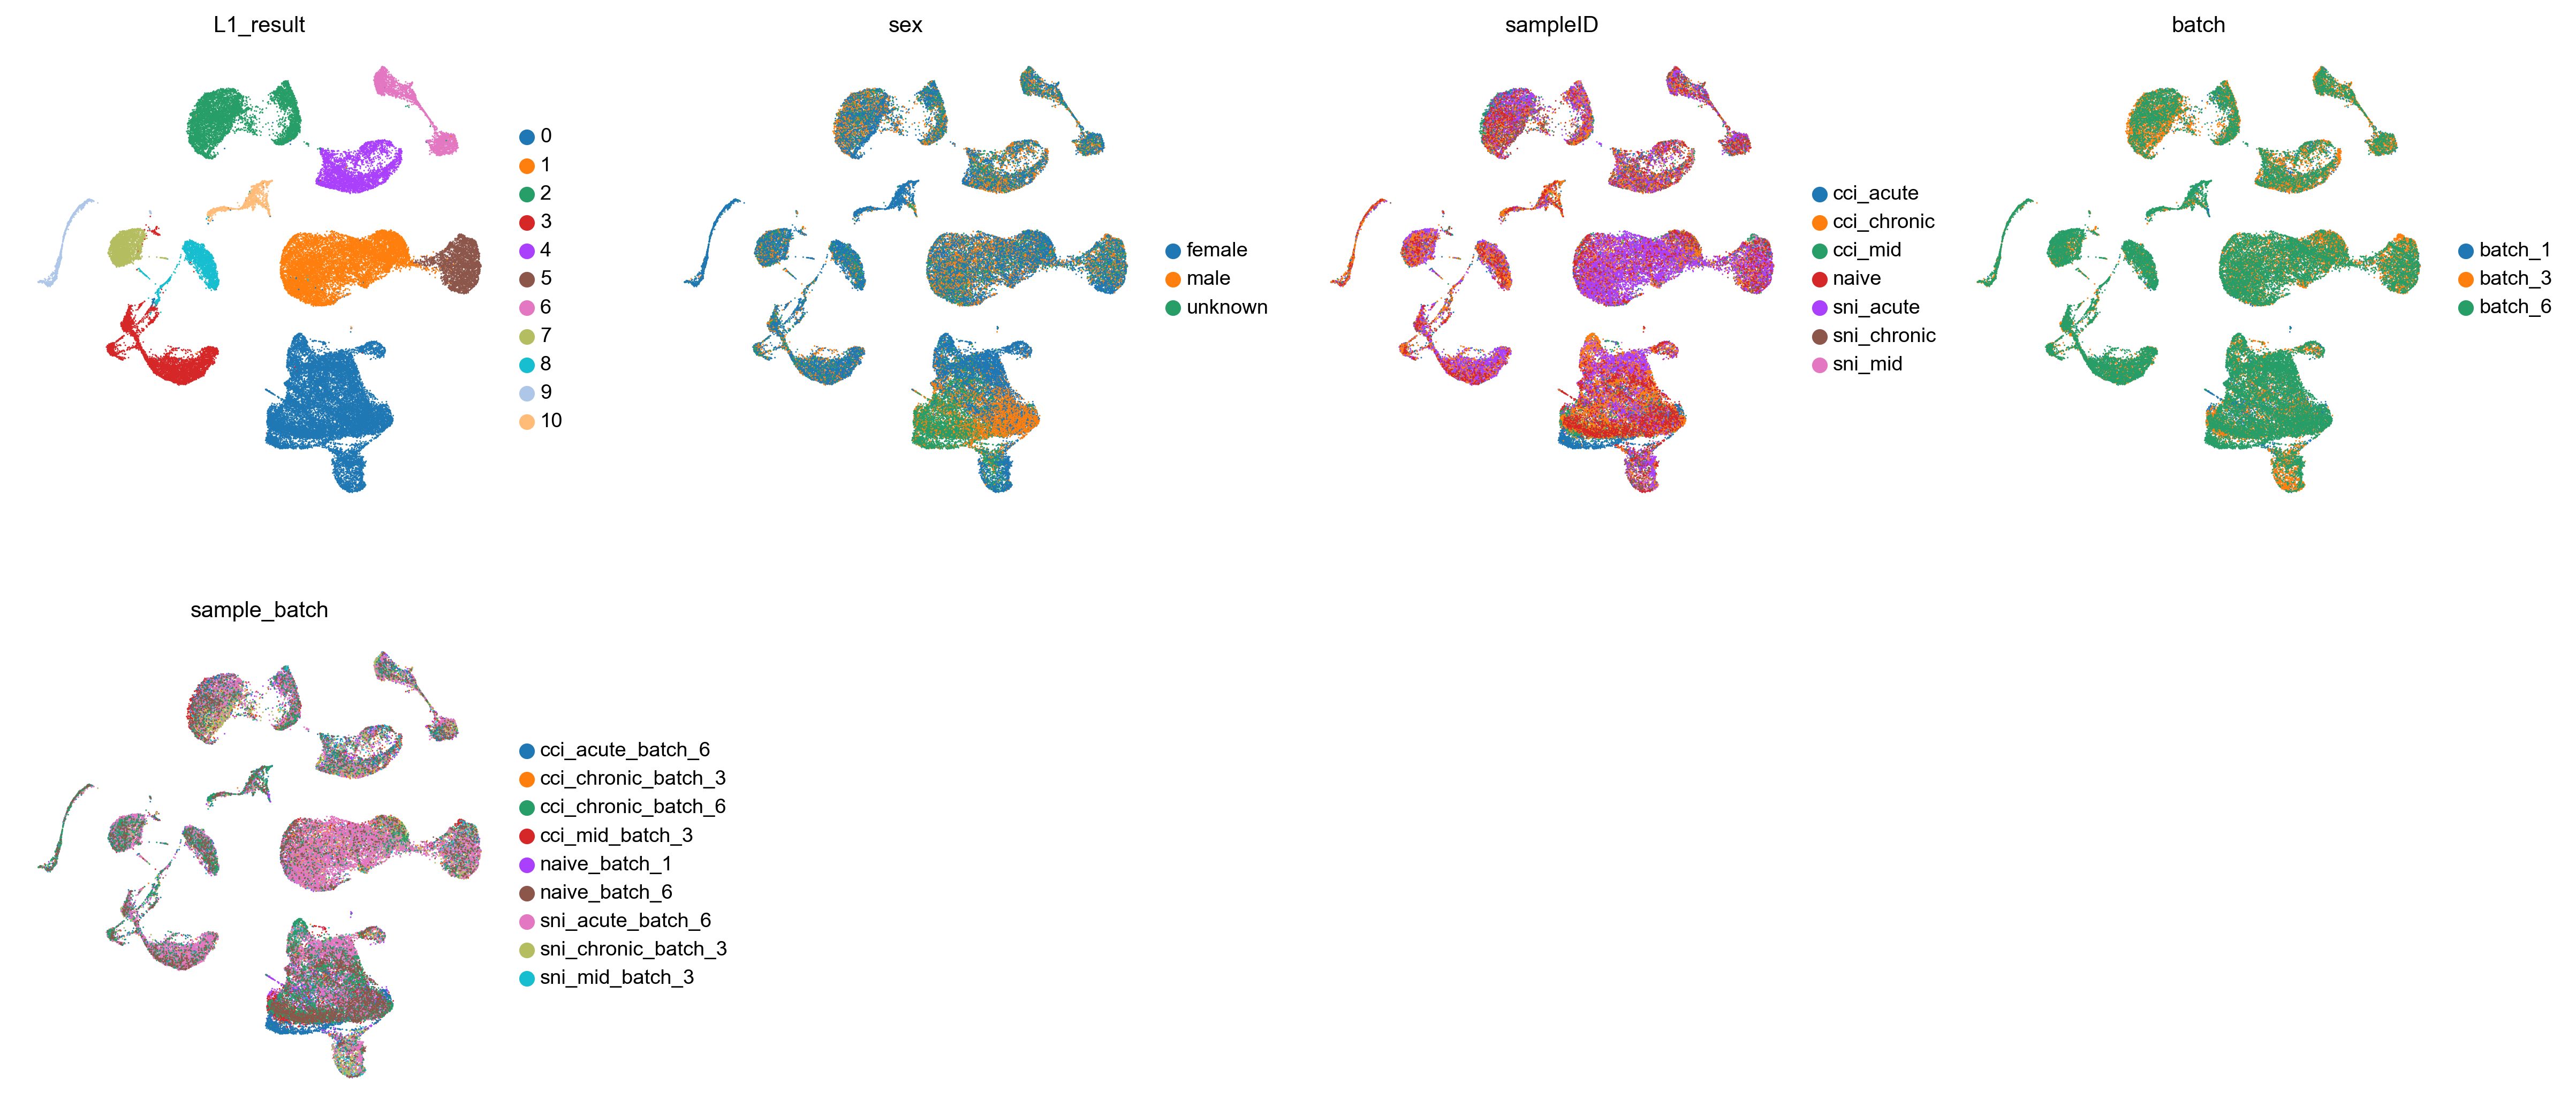

In [ ]:
# Initial UMAPs
# Convert the columns to categorical type
categorical_columns = ["L1_result", "sex", "sampleID", "batch", "sample_batch"]

for col in categorical_columns:
    adata.obs[col] = adata.obs[col].astype('category')

# Generate the UMAP
sc.pl.umap(adata, color = ["L1_result", "sex", "sampleID", "batch", "sample_batch"], size=2)

In [146]:
# Now save the Clustered AnnData object
adata.write('allcells_r0.01-0.03_cl.h5ad')

In [ ]:
# Save csv file
pd.DataFrame(adata.obs['L1_result']).to_csv('allcells_r0.01-0.03_cl.csv')